|--== Breadth First Search ==--|

In [18]:
graph = {
    '5': ['3', '7'],
    '3': ['2', '4'],
    '7': ['8'],
    '2': [],
    '4': ['8'],
    '8': []
}
visited = []
queue = []
def bfs(graph, node, goal):
    visited.append(node)
    queue.append(node)
    while queue:
        m = queue.pop(0)
        print(m, end = " ")
        if m == goal:
            print("Goal Found!")
            return
        for neighbour in graph[m]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)
    print("Goal Not Found!")
bfs(graph, '5', '8')

5 3 7 2 4 8 Goal Found!


|--== Depth First Search ==--|

In [19]:
graph = {
    '5': ['3', '7'],
    '3': ['2', '4'],
    '7': ['8'],
    '2': [],
    '4': ['8'],
    '8': []
}
visited = []
def dfs(graph, node, goal, visited):
    if node not in visited:
        visited.append(node)
        print(node, end=" ")
        if node == goal:
            print("Goal Found!")
            return True
        for neighbour in graph[node]:
            if dfs(graph, neighbour, goal, visited):
                return True
    return False
dfs(graph, '5', '8', visited)

5 3 2 4 8 Goal Found!


True

|--== Best First Search ==--|

In [20]:
from queue import PriorityQueue
graph = {
    'A': [('B', 4), ('C', 3)],
    'B': [('D', 5), ('E', 12)],
    'C': [('F', 7)],
    'D': [],
    'E': [],
    'F': []
}
heuristic = {
    'A': 14,
    'B': 12,
    'C': 11,
    'D': 6,
    'E': 4,
    'F': 0
}
visited = []
def best_fs(start, goal):
    pq = PriorityQueue()
    pq.put((heuristic[start],start))
    while not pq.empty():
        h, node = pq.get()
        if node not in visited:
            print(node, end=" ")
            visited.append(node)
            if node == goal:
                print("Goal Reached!")
                return
            for neighbour, cost in graph[node]:
                if neighbour not in visited:
                    pq.put((heuristic[neighbour], neighbour))
best_fs('A', 'F')

A C F Goal Reached!


--== A* Algorithm ==--

In [93]:
from queue import PriorityQueue
graph = {
    'A': [('B', 1), ('C', 3)],
    'B': [('D', 1), ('E', 5)],
    'C': [('F', 2)],
    'D': [],
    'E': [],
    'F': []
}

heuristic = {
    'A': 6,
    'B': 4,
    'C': 4,
    'D': 0,
    'E': 2,
    'F': 1
}
visited = []
def a_star(start, goal):
    pq = PriorityQueue()
    pq.put((heuristic[start], 0, start))
    while not pq.empty():
        f, cost, node = pq.get()
        if node not in visited:
            print(node, end=" ")
            visited.append(node)
            if node == goal:
                print("\nGoal Reached")
                return
            for neighbour, weight in graph[node]:
                g = cost + weight
                h = heuristic[neighbour]
                f = g + h
                pq.put((f, g, neighbour))
a_star('A', 'D')

A B D 
Goal Reached


|--== Traveling Salseman Problem --==|

In [86]:
import sys
graph = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]
n = len(graph)
visited = [False] * n
min_cost = sys.maxsize
def tsp(city, count, cost):
    global min_cost
    if count == n and graph[city][0]:
        min_cost = min(min_cost, cost + graph[city][0])
        return
    for i in range(n):
        if not visited[i] and graph[city][i]:
            visited[i] = True
            tsp(i, count + 1, cost + graph[city][i])
            visited[i] = False
visited[0] = True
tsp(0, 1, 0)
print("Minimum Cost:", min_cost)

Minimum Cost: 80


|--== Hill Climbing & Steepest Ascent Hill Climbing ==--|

In [87]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}
heuristic = {
    'A': 6,
    'B': 4,
    'C': 5,
    'D': 1,
    'E': 2,
    'F': 3
}
def hill_climbing(start):
    current = start
    path = [current]
    while True:
        neighbours = graph[current]
        next_node = None
        for neighbour in neighbours:
            if heuristic[neighbour] < heuristic[current]:
                next_node = neighbour
                break
        if next_node is None:
            break
        current = next_node
        path.append(current)
    print("Hill Climbing Path:")
    print(" -> ".join(path))
def steepest_ascent(start):
    current = start
    path = [current]
    while True:
        neighbours = graph[current]
        best = current
        for neighbour in neighbours:
            if heuristic[neighbour] < heuristic[best]:
                best = neighbour
        if best == current:
            break
        current = best
        path.append(current)
    print("Steepest Ascent Path:")
    print(" -> ".join(path))
hill_climbing('A')
steepest_ascent('A')

Hill Climbing Path:
A -> B -> D
Steepest Ascent Path:
A -> B -> D


|--== Google Colab ==--|

In [88]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
for file_name in uploaded.keys():
    df = pd.read_csv(file_name)
    print("File Loaded Successfully")
    print(df.head())

ModuleNotFoundError: No module named 'google.colab'

|--== Pandas on Titanic Dataset ==--|

In [89]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
print("First 5 Rows")
print(df.head())
print("\nLast 5 Rows")
print(df.tail())
print("\nColumn Names")
print(df.columns)
print("\nDataset Information")
print(df.info())
print("\nStatistical Summary")
print(df.describe())
print("\nMissing Values")
print(df.isnull().sum())
print("\nPassengers Age > 30")
print(df[df['Age'] > 30].head())
print("\nSurvived Passengers")
print(df[df['Survived'] == 1].head())
print("\nAverage Values Grouped By Pclass")
print(df.groupby('Pclass').mean(numeric_only=True))
print("\nSort By Fare")
print(df.sort_values(by='Fare', ascending=False).head())
print("\nUnique Embarked Values")
print(df['Embarked'].unique())
print("\nSurvival Count")
print(df['Survived'].value_counts())

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

|--== Python + SQL ==--|

In [90]:
import sqlite3
conn = sqlite3.connect("student.db")

cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS students(
    id INTEGER PRIMARY KEY,
    name TEXT,
    age INTEGER,
    marks REAL
)
""")

cur.executemany(
    "INSERT INTO students(name, age, marks) VALUES(?,?,?)",
    [
        ('Aman', 20, 85),
        ('Riya', 21, 90),
        ('Karan', 19, 78)
    ]
)

conn.commit()

print("Initial Records")
print(cur.execute("SELECT * FROM students").fetchall())

cur.execute(
    "UPDATE students SET marks = 88 WHERE name = 'Aman'"
)

cur.execute(
    "DELETE FROM students WHERE name = 'Karan'"
)

conn.commit()

print("\nUpdated Records")
print(cur.execute("SELECT * FROM students").fetchall())

conn.close()

Initial Records
[(1, 'Aman', 20, 88.0), (2, 'Riya', 21, 90.0), (3, 'Aman', 20, 85.0), (4, 'Riya', 21, 90.0), (5, 'Karan', 19, 78.0)]

Updated Records
[(1, 'Aman', 20, 88.0), (2, 'Riya', 21, 90.0), (3, 'Aman', 20, 88.0), (4, 'Riya', 21, 90.0)]


|--== Basic Linear Regression Model ==--|

In [91]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1], [2], [3], [4], [5]])

y = np.array([2, 4, 6, 8, 10])

model = LinearRegression()

model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

y_pred = model.predict(X)

print("Predicted Values:")
print(y_pred)

new_value = np.array([[6]])

print("Prediction for 6:")
print(model.predict(new_value)[0])

Coefficient: 2.0
Intercept: 0.0
Predicted Values:
[ 2.  4.  6.  8. 10.]
Prediction for 6:
12.0


|--== Matplot ==--|

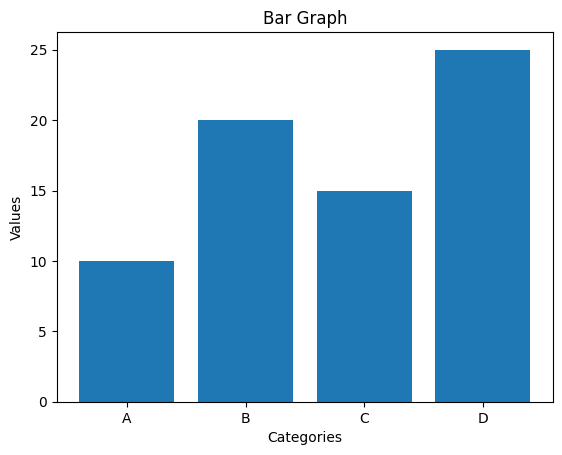

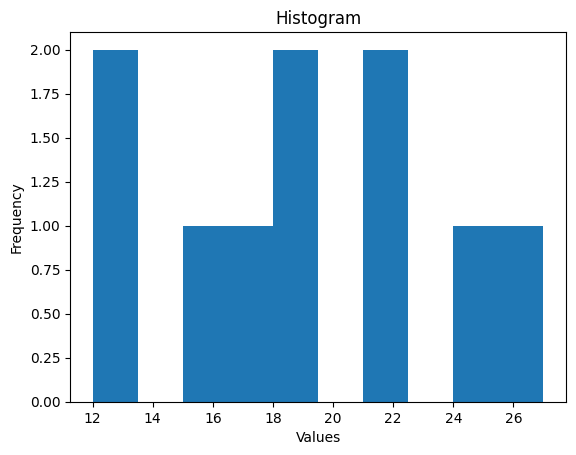

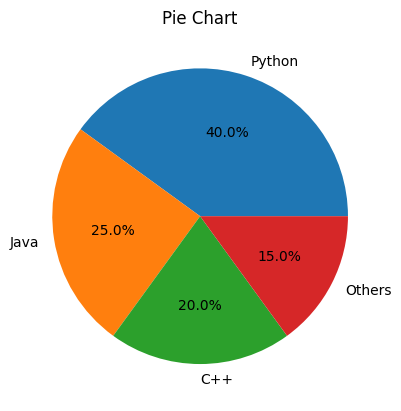

In [92]:
import matplotlib.pyplot as plt
categories = ['A', 'B', 'C', 'D']
values = [10, 20, 15, 25]
plt.bar(categories, values)
plt.title("Bar Graph")
plt.xlabel("Categories")
plt.ylabel("Values")
plt.show()
data = [12, 15, 13, 17, 18, 19, 21, 22, 25, 27]
plt.hist(data, bins=10)
plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()
labels = ['Python', 'Java', 'C++', 'Others']
sizes = [40, 25, 20, 15]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.show()